# **Importing Required Libraries**

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn import tree
import matplotlib.pyplot as plt

# **Data Overview**

In [ ]:
df=pd.read_csv('/content/sample_data/Loan.csv')
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [ ]:
df.head(10)

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0
5,2018-01-06,37,178310,626,Self-Employed,Master,16,15433,72,Married,...,14859.166667,0.756079,5,27071,0.217433,0.217601,385.577074,0.075211,1,44.0
6,2018-01-07,58,51250,564,Employed,High School,39,12741,48,Married,...,4270.833333,0.884275,5,21730,0.225741,0.205271,391.300352,0.170529,0,50.0
7,2018-01-08,49,97345,516,Employed,High School,23,19634,12,Divorced,...,8112.083333,0.933492,5,38621,0.226634,0.209113,1827.360055,0.260767,1,42.4
8,2018-01-09,34,116841,603,Employed,Bachelor,12,55353,60,Divorced,...,9736.750000,0.728397,3,7711,0.258853,0.291539,1762.199026,0.246509,0,61.0
9,2018-01-10,46,40615,612,Employed,Associate,19,25443,12,Married,...,3384.583333,0.615323,3,116812,0.184443,0.197271,2353.577424,0.903384,0,53.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [ ]:
df.isnull().sum()

,0
ApplicationDate,0
Age,0
AnnualIncome,0
CreditScore,0
EmploymentStatus,0
EducationLevel,0
Experience,0
LoanAmount,0
LoanDuration,0
MaritalStatus,0


# **Feature Selection**

In [ ]:
drop_cols = ["ApplicationDate", "EducationLevel", "MaritalStatus", "Experience", "InterestRate", "MonthlyLoanPayment", "RiskScore", "CreditCardUtilizationRate", "NumberOfCreditInquiries", "DebtToIncomeRatio", "CheckingAccountBalance", "TotalAssets", "TotalLiabilities", "MonthlyIncome", "UtilityBillsPaymentHistory", "BaseInterestRate", "InterestRate", "MonthlyLoanPayment", "RiskScore"]
df = df.drop(columns=drop_cols, errors='ignore')

# **Correlation Heatmap**

In [ ]:

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()
display(correlation_matrix)

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,JobTenure,NetWorth,TotalDebtToIncomeRatio,LoanApproved
Age,1.000000,0.144774,0.323243,-0.007492,-0.006992,-0.000287,0.015685,-0.001069,0.010817,-0.003684,-0.002487,-0.000139,0.004236,-0.000773,0.014061,-0.111800,0.141029
AnnualIncome,0.144774,1.000000,0.104045,-0.004116,0.002972,-0.001244,-0.001082,-0.008175,0.003816,0.004302,0.003715,-0.005365,-0.001397,-0.000610,-0.004358,-0.532033,0.597900
CreditScore,0.323243,0.104045,1.000000,-0.010834,-0.000762,-0.014453,0.011153,-0.008780,0.008638,-0.007690,0.004295,0.005217,-0.006316,0.008069,0.001951,-0.115363,0.142000
LoanAmount,-0.007492,-0.004116,-0.010834,1.000000,-0.000436,-0.007005,0.021103,0.000769,0.004844,-0.002352,-0.002811,0.000580,0.001489,0.005364,-0.003679,0.457175,-0.239496
LoanDuration,-0.006992,0.002972,-0.000762,-0.000436,1.000000,-0.001301,0.000068,0.001489,-0.000434,0.015646,0.001983,0.013693,0.001579,0.003635,-0.008779,-0.213984,-0.094558
NumberOfDependents,-0.000287,-0.001244,-0.014453,-0.007005,-0.001301,1.000000,-0.002396,0.006033,-0.001154,0.006116,0.001281,0.002705,-0.002080,0.010910,-0.008423,-0.000358,0.001717
MonthlyDebtPayments,0.015685,-0.001082,0.011153,0.021103,0.000068,-0.002396,1.000000,0.006280,-0.007493,0.002713,-0.003347,-0.004115,-0.004223,0.005863,0.004430,0.219453,-0.070415
NumberOfOpenCreditLines,-0.001069,-0.008175,-0.008780,0.000769,0.001489,0.006033,0.006280,1.000000,-0.001612,0.012600,0.002388,0.003653,0.009167,0.007298,-0.002013,0.003471,-0.004769
BankruptcyHistory,0.010817,0.003816,0.008638,0.004844,-0.000434,-0.001154,-0.007493,-0.001612,1.000000,-0.004376,0.007335,0.009696,0.006862,0.004436,-0.000833,-0.000702,-0.070751
PreviousLoanDefaults,-0.003684,0.004302,-0.007690,-0.002352,0.015646,0.006116,0.002713,0.012600,-0.004376,1.000000,0.002079,0.005503,0.002616,0.003628,0.008605,-0.000458,-0.065343


In [ ]:

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()
fig = px.imshow(
    correlation_matrix,
    text_auto=True,
    aspect="auto",
    title='Correlation Matrix',
    color_continuous_scale='Viridis'
)
fig.update_layout(
    xaxis_title="Features",
    yaxis_title="Features",
    height=900,
    width=900
)
fig.show()

# **Visualizing imbalance of the target variable**

In [ ]:
target_counts = df['LoanApproved'].value_counts()
target_perc = df['LoanApproved'].value_counts(normalize=True) * 100
fig = px.bar(
    x=target_counts.index.astype(str),
    y=target_counts.values,
    text=[f"{p:.2f}%" for p in target_perc],
    labels={'x':'LoanApproved', 'y':'Count'},
    title="Distribution of Loan Approval",
    height=600,
    width=600,
    color=target_counts.index.astype(str),
    color_discrete_sequence=['#636EFA', '#EF553B']
)

fig.update_traces(textposition='outside', showlegend=False)
fig.show()

# **Label Encoding of Categorical columns**

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nData types after encoding:")
print(df.dtypes)

Categorical columns to encode: ['EmploymentStatus', 'HomeOwnershipStatus', 'LoanPurpose']

Data types after encoding:
Age                          int64
AnnualIncome                 int64
CreditScore                  int64
EmploymentStatus             int64
LoanAmount                   int64
LoanDuration                 int64
NumberOfDependents           int64
HomeOwnershipStatus          int64
MonthlyDebtPayments          int64
NumberOfOpenCreditLines      int64
BankruptcyHistory            int64
LoanPurpose                  int64
PreviousLoanDefaults         int64
PaymentHistory               int64
LengthOfCreditHistory        int64
SavingsAccountBalance        int64
JobTenure                    int64
NetWorth                     int64
TotalDebtToIncomeRatio     float64
LoanApproved                 int64
dtype: object


# **Imbalance Correction Using SMOTE**

In [ ]:
X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: LoanApproved
0    12176
1     3824
Name: count, dtype: int64
After SMOTE: LoanApproved
0    12176
1    12176
Name: count, dtype: int64


# **Understanding data using visualization**

In [ ]:
fig2 = px.box(
    df, x='LoanApproved', y='CreditScore', color='LoanApproved',
    color_discrete_sequence=['salmon', 'lightgreen'],
    title='Credit Score Distribution by Loan Approval',
    height=600, width=600
)
fig2.update_layout(showlegend=True)
fig2.show()

In [ ]:
fig = px.scatter(
    df, x='TotalDebtToIncomeRatio', y='LoanAmount', color='LoanApproved',
    color_discrete_sequence=['salmon','lightgreen'],
    size='AnnualIncome', hover_data=['CreditScore', 'NetWorth'],
    title='Debt-to-Income vs Loan Amount by Approval',
    height=600, width=700
)
fig.show()

In [ ]:
temp = df.groupby(['BankruptcyHistory','LoanApproved']).size().reset_index(name='count')
temp['percentage'] = temp['count'] / temp.groupby('BankruptcyHistory')['count'].transform('sum') * 100

fig = px.bar(
    temp,
    x='BankruptcyHistory',
    y='count',
    color='LoanApproved',
    text=temp['percentage'].apply(lambda x: f"{x:.2f}%"),
    barmode='stack',
    color_discrete_sequence=['salmon','lightgreen'],
    title='Bankruptcy History vs Loan Approval',
    labels={'BankruptcyHistory': 'Bankruptcy History', 'LoanApproved': 'Loan Approved Status'},
    height=600, width=700
)
fig.update_traces(textposition='outside')
fig.update_layout(xaxis={'categoryorder':'category ascending'})
fig.show()

In [ ]:
temp = df.groupby(['PreviousLoanDefaults','LoanApproved']).size().reset_index(name='count')
temp['percentage'] = temp['count'] / temp.groupby('PreviousLoanDefaults')['count'].transform('sum') * 100

fig = px.bar(
    temp,
    x='PreviousLoanDefaults',
    y='count',
    color='LoanApproved',
    text=temp['percentage'].apply(lambda x: f"{x:.2f}%"),
    barmode='stack',
    color_discrete_sequence=['salmon','lightgreen'],
    title='Previous Loan Defaults vs Loan Approval',
    labels={'PreviousLoanDefaults': 'Previous Loan Defaults', 'LoanApproved': 'Loan Approved Status'},
    height=600, width=700
)
fig.update_traces(textposition='outside')
fig.update_layout(xaxis={'categoryorder':'category ascending'})
fig.show()

In [ ]:
temp = df.groupby(['EmploymentStatus','LoanApproved']).size().reset_index(name='count')
temp['percentage'] = temp['count'] / temp.groupby('EmploymentStatus')['count'].transform('sum') * 100

status_labels = {0: "Employed", 1: "Self-employed", 2: "Unemployed"}
temp['EmploymentStatusLabel'] = temp['EmploymentStatus'].map(status_labels)

fig = px.bar(
    temp,
    x='EmploymentStatusLabel',
    y='count',
    color='LoanApproved',
    text=temp['percentage'].apply(lambda x: f"{x:.2f}%"),
    barmode='stack',
    color_discrete_sequence=['salmon','lightgreen'],
    title='Employment Status vs Loan Approval',
    height=600, width=800
)

fig.update_traces(textposition='outside')

fig.update_xaxes(title="Employment Status")

fig.show()

In [ ]:

fig_loan_amount = px.histogram(
    df,
    x='LoanAmount',
    color='LoanApproved',
    marginal='box',
    nbins=50,
    title='Distribution of Loan Amount by Approval',
    color_discrete_sequence=['salmon', 'lightgreen'],
    height=600,
    width=800
)
fig_loan_amount.show()
fig_loan_duration = px.histogram(
    df,
    x='LoanDuration',
    color='LoanApproved',
    marginal='box',
    nbins=50,
    title='Distribution of Loan Duration by Approval',
    color_discrete_sequence=['salmon', 'lightgreen'],
    height=600,
    width=800
)
fig_loan_duration.show()

In [ ]:
temp = df.groupby(['LoanPurpose','LoanApproved']).size().reset_index(name='count')
temp['percentage'] = temp['count'] / temp.groupby('LoanPurpose')['count'].transform('sum') * 100
purpose_labels = {
    0: "Auto",
    1: "Debt Consolidation",
    2: "Education",
    3: "Home",
    4: "Other"
}

temp['LoanPurposeLabel'] = temp['LoanPurpose'].map(purpose_labels)
loan_approved_map = {0: 'Not Approved', 1: 'Approved'}
temp['LoanApproved_Label'] = temp['LoanApproved'].map(loan_approved_map)


fig = px.bar(
    temp,
    x='LoanPurposeLabel',
    y='count',
    color='LoanApproved_Label',
    text=temp['percentage'].apply(lambda x: f"{x:.2f}%"),
    barmode='stack',
    color_discrete_sequence=['salmon','lightgreen'],
    title='Loan Purpose vs Loan Approval',
    labels={'LoanPurposeLabel': 'Loan Purpose', 'LoanApproved_Label': 'Loan Approved Status'}, # Update labels
    height=600, width=800
)

fig.update_traces(textposition='outside')
fig.update_layout(xaxis={'categoryorder': 'array',
                         'categoryarray': ["Home", "Debt Consolidation", "Auto", "Education", "Other"]})
fig.show()

# **Feature Scaling**

In [ ]:
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train_res)
X_test_scaled = scaler_lr.transform(X_test)
print("Features scaled using StandardScaler")

Features scaled using StandardScaler


# **Logistic Regression Implementation**

In [ ]:
print("\nHyperparameter Tuning")
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_scaled, y_train_res)
print(f"Best parameters: {lr_grid.best_params_}")
print(f"Best cross-validation score: {lr_grid.best_score_:.4f}")


Hyperparameter Tuning
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation score: 0.9803


In [ ]:
print("\nTraining Final Logistic Regression Model")
lr_model = lr_grid.best_estimator_
lr_model.fit(X_train_scaled, y_train_res)


Training Final Logistic Regression Model


LogisticRegression(C=1, max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')

In [ ]:

y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba_lr)

In [ ]:
lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train_res, cv=5, scoring='accuracy')

In [ ]:
print(f"\nLogistic Regression Results")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"ROC AUC: {lr_roc_auc:.4f}")
print(f"Cross-validation: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std() * 2:.4f})")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print(f"\nConfusion Matrix:")
lr_cm = confusion_matrix(y_test, y_pred_lr)
print(lr_cm)


Logistic Regression Results
Accuracy: 0.9093
ROC AUC: 0.9710
Cross-validation: 0.9250 (+/- 0.0278)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      3044
           1       0.76      0.90      0.83       956

    accuracy                           0.91      4000
   macro avg       0.86      0.91      0.88      4000
weighted avg       0.92      0.91      0.91      4000


Confusion Matrix:
[[2777  267]
 [  96  860]]


In [ ]:
# Feature importance for Logistic Regression
import numpy as np
print(f"\nFeature Importance (Coefficients)")
feature_importance_lr = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance_lr.head(10))


Feature Importance (Coefficients)
Top 10 Most Important Features:
                   Feature  Coefficient  Abs_Coefficient
18  TotalDebtToIncomeRatio    -6.327088         6.327088
1             AnnualIncome     2.321896         2.321896
17                NetWorth     2.008791         2.008791
5             LoanDuration    -1.577222         1.577222
4               LoanAmount    -1.146702         1.146702
14   LengthOfCreditHistory     0.893032         0.893032
10       BankruptcyHistory    -0.839927         0.839927
12    PreviousLoanDefaults    -0.758692         0.758692
2              CreditScore     0.511410         0.511410
3         EmploymentStatus    -0.430420         0.430420


In [ ]:

intercept = lr_model.intercept_[0]
coefficients = lr_model.coef_[0]
feature_names = X.columns

equation = f"z = {intercept:.4f}"

for i, coef in enumerate(coefficients):
    feature_name = feature_names[i]
    if coef >= 0:
        equation += f" + {coef:.4f} * {feature_name}"
    else:
        equation += f" - {-coef:.4f} * {feature_name}"

print("Specific Logistic Regression Equation (z):")
print(equation)

Specific Logistic Regression Equation (z):
z = -1.8571 + 0.1470 * Age + 2.3219 * AnnualIncome + 0.5114 * CreditScore - 0.4304 * EmploymentStatus - 1.1467 * LoanAmount - 1.5772 * LoanDuration - 0.2019 * NumberOfDependents - 0.4155 * HomeOwnershipStatus + 0.2214 * MonthlyDebtPayments - 0.1040 * NumberOfOpenCreditLines - 0.8399 * BankruptcyHistory - 0.2058 * LoanPurpose - 0.7587 * PreviousLoanDefaults + 0.1799 * PaymentHistory + 0.8930 * LengthOfCreditHistory + 0.0257 * SavingsAccountBalance - 0.0719 * JobTenure + 2.0088 * NetWorth - 6.3271 * TotalDebtToIncomeRatio


# **XGBoost Implementation**

In [ ]:

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

print("Performing hyperparameter tuning for XGBoost...")
xgb_grid = GridSearchCV(
    xgb_model,
    param_grid_xgb,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train_res, y_train_res)
print(f"Best XGBoost parameters: {xgb_grid.best_params_}")
print(f"Best XGBoost CV score: {xgb_grid.best_score_:.4f}")

Performing hyperparameter tuning for XGBoost...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best XGBoost parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best XGBoost CV score: 0.9886


In [ ]:

xgb_final = xgb_grid.best_estimator_
xgb_final.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:

y_pred_xgb = xgb_final.predict(X_test)
y_pred_proba_xgb = xgb_final.predict_proba(X_test)[:, 1]

In [ ]:

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_pred_proba_xgb)
xgb_cv_scores = cross_val_score(xgb_final, X_train_res, y_train_res, cv=5, scoring='accuracy')

In [ ]:
print(f"\nXGBoost Results")
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"ROC AUC: {xgb_roc_auc:.4f}")
print(f"Cross-validation: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std() * 2:.4f})")

print(f"\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print(f"\nXGBoost Confusion Matrix:")
xgb_cm = confusion_matrix(y_test, y_pred_xgb)
print(xgb_cm)


XGBoost Results
Accuracy: 0.9175
ROC AUC: 0.9700
Cross-validation: 0.9444 (+/- 0.0553)

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      3044
           1       0.82      0.84      0.83       956

    accuracy                           0.92      4000
   macro avg       0.88      0.89      0.89      4000
weighted avg       0.92      0.92      0.92      4000


XGBoost Confusion Matrix:
[[2866  178]
 [ 152  804]]


In [ ]:

xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'XGBoost_Importance': xgb_final.feature_importances_
}).sort_values('XGBoost_Importance', ascending=False)

In [ ]:
print("XGBoost - Top 10 Feature Importances:")
print(xgb_importance.head(10))


XGBoost - Top 10 Feature Importances:
                   Feature  XGBoost_Importance
18  TotalDebtToIncomeRatio            0.265433
5             LoanDuration            0.131183
12    PreviousLoanDefaults            0.112697
10       BankruptcyHistory            0.111599
3         EmploymentStatus            0.056442
17                NetWorth            0.047736
1             AnnualIncome            0.046396
7      HomeOwnershipStatus            0.032786
14   LengthOfCreditHistory            0.032117
0                      Age            0.021208


# **Random Forest Implementation**

In [ ]:

print("\nRandom Forest")

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth':  [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_model = RandomForestClassifier(random_state=42)

print("Performing hyperparameter tuning for Random Forest...")
rf_grid = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_res, y_train_res)
print(f" Best Random Forest parameters: {rf_grid.best_params_}")
print(f" Best Random Forest CV score: {rf_grid.best_score_:.4f}")


Random Forest
Performing hyperparameter tuning for Random Forest...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
 Best Random Forest parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
 Best Random Forest CV score: 0.9851


In [ ]:

rf_final = rf_grid.best_estimator_
rf_final.fit(X_train_res, y_train_res)

RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:

y_pred_rf = rf_final.predict(X_test)
y_pred_proba_rf = rf_final.predict_proba(X_test)[:, 1]

In [ ]:

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)
rf_cv_scores = cross_val_score(rf_final, X_train_res, y_train_res, cv=5, scoring='accuracy')

print(f"\nRandom Forest Results")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"ROC AUC: {rf_roc_auc:.4f}")
print(f"Cross-validation: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std() * 2:.4f})")

print(f"\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print(f"\nRandom Forest Confusion Matrix:")
rf_cm = confusion_matrix(y_test, y_pred_rf)
print(rf_cm)


Random Forest Results
Accuracy: 0.9127
ROC AUC: 0.9648
Cross-validation: 0.9393 (+/- 0.0406)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      3044
           1       0.80      0.85      0.82       956

    accuracy                           0.91      4000
   macro avg       0.87      0.89      0.88      4000
weighted avg       0.92      0.91      0.91      4000


Random Forest Confusion Matrix:
[[2837  207]
 [ 142  814]]


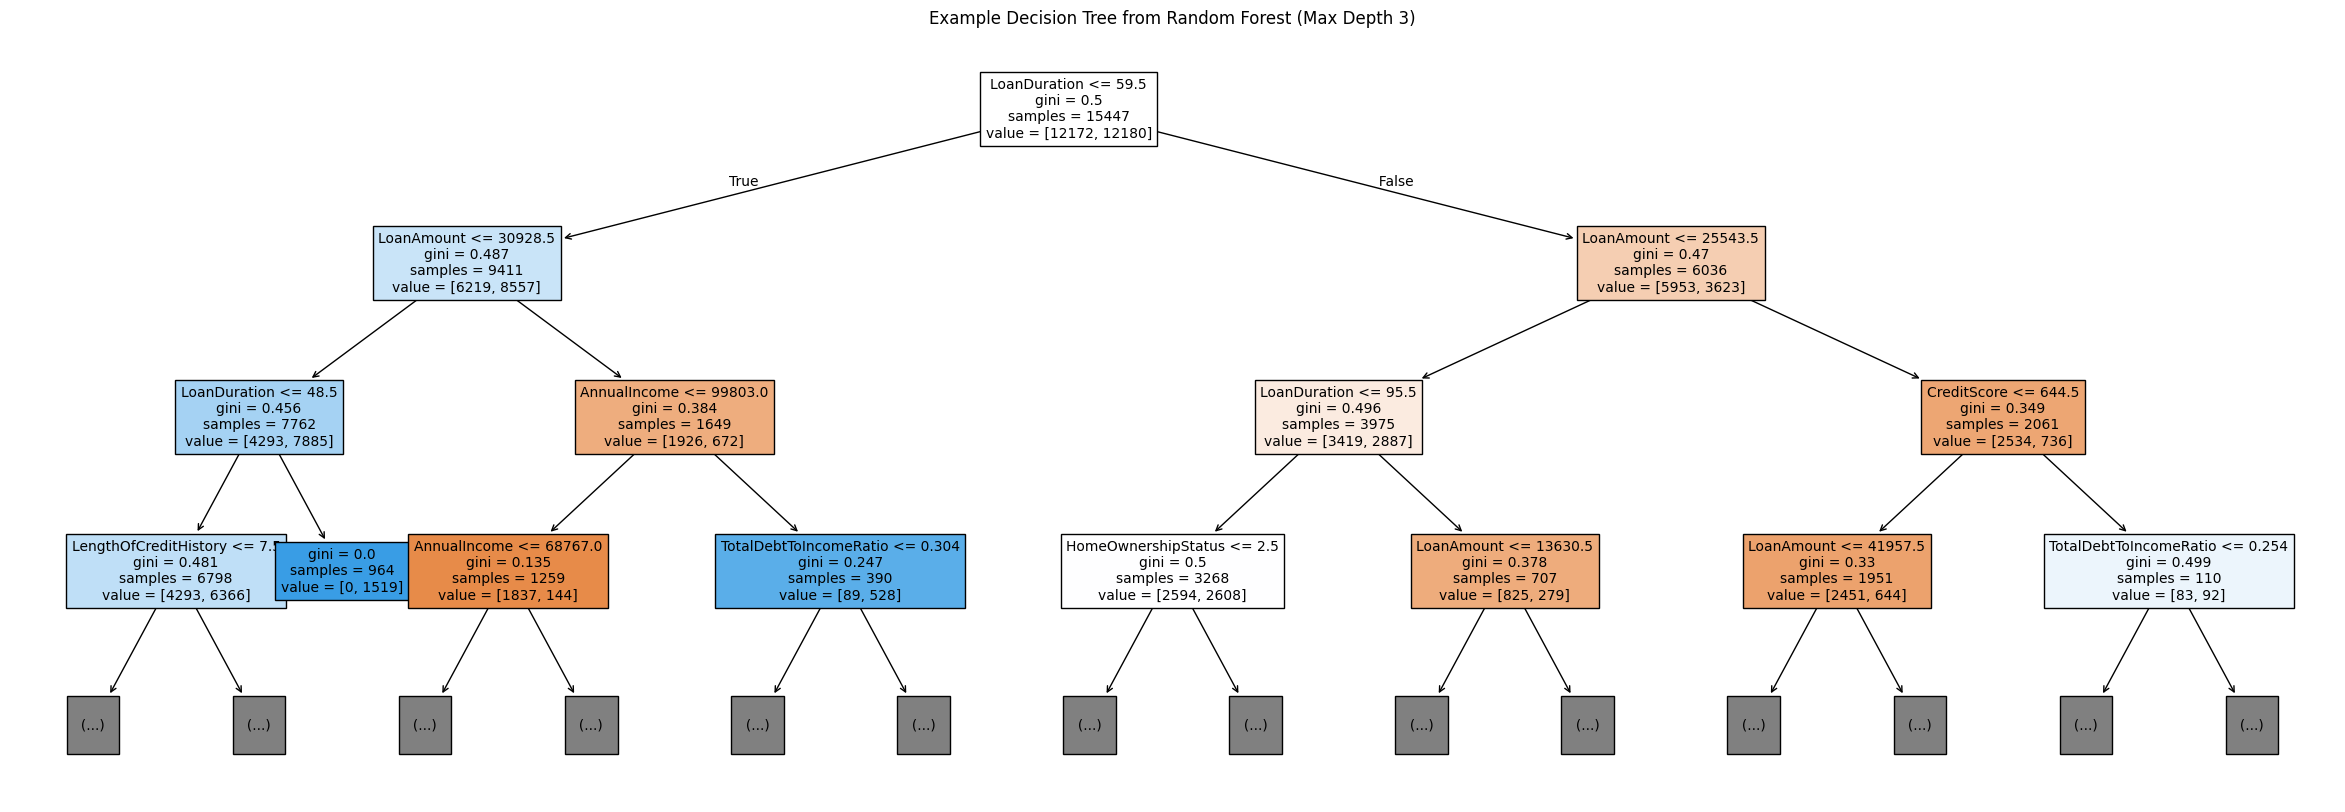

In [ ]:

single_tree = rf_final.estimators_[0]


plt.figure(figsize=(30,10))
tree.plot_tree(single_tree, feature_names=X.columns, filled=True, max_depth=3, fontsize=10)
plt.title("Example Decision Tree from Random Forest (Max Depth 3)")
plt.show()

# **Support Vector Machine (SVM) Implementation**

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

print("\nHyperparameter Tuning for SVM")
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear'],
    'class_weight': ['balanced', None]
}

svm_model = SVC(random_state=42, probability=True)

print("Performing hyperparameter tuning for SVM...")
svm_grid = GridSearchCV(
    svm_model,
    param_grid_svm,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_scaled, y_train_res)
print(f"Best SVM parameters: {svm_grid.best_params_}")
print(f"Best SVM CV score: {svm_grid.best_score_:.4f}")


Hyperparameter Tuning for SVM
Performing hyperparameter tuning for SVM...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best SVM parameters: {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM CV score: 0.9800


In [ ]:

svm_final = svm_grid.best_estimator_
svm_final.fit(X_train_scaled, y_train_res)

SVC(C=10, probability=True, random_state=42)

In [ ]:

y_pred_svm = svm_final.predict(X_test_scaled)
y_pred_proba_svm = svm_final.predict_proba(X_test_scaled)[:, 1]

In [ ]:

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_roc_auc = roc_auc_score(y_test, y_pred_proba_svm)
svm_cv_scores = cross_val_score(svm_final, X_train_scaled, y_train_res, cv=5, scoring='accuracy')

In [ ]:
print(f"\nSVM Results")
print(f"Accuracy: {svm_accuracy:.4f}")
print(f"ROC AUC: {svm_roc_auc:.4f}")
print(f"Cross-validation: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std() * 2:.4f})")

print(f"\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

print(f"\nSVM Confusion Matrix:")
svm_cm = confusion_matrix(y_test, y_pred_svm)
print(svm_cm)


SVM Results
Accuracy: 0.8988
ROC AUC: 0.9600
Cross-validation: 0.9327 (+/- 0.0468)

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      3044
           1       0.76      0.84      0.80       956

    accuracy                           0.90      4000
   macro avg       0.85      0.88      0.87      4000
weighted avg       0.90      0.90      0.90      4000


SVM Confusion Matrix:
[[2796  248]
 [ 157  799]]


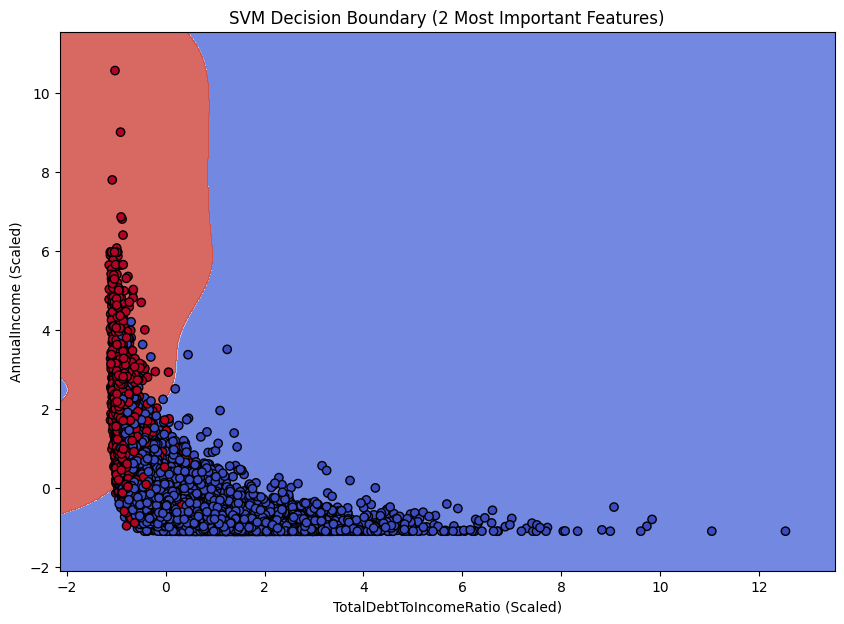

In [ ]:

X_2d = X[['TotalDebtToIncomeRatio', 'AnnualIncome']]
y_2d = y


scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

svm_2d_model = SVC(kernel='rbf', random_state=42, probability=True)

svm_2d_model.fit(X_2d_scaled, y_2d)

x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = svm_2d_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

plt.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('TotalDebtToIncomeRatio (Scaled)')
plt.ylabel('AnnualIncome (Scaled)')
plt.title('SVM Decision Boundary (2 Most Important Features)')
plt.show()

In [ ]:

y_pred_svm_2d = svm_2d_model.predict(X_2d_scaled)
y_pred_proba_svm_2d = svm_2d_model.predict_proba(X_2d_scaled)[:, 1]

svm_2d_accuracy = accuracy_score(y_2d, y_pred_svm_2d)
svm_2d_roc_auc = roc_auc_score(y_2d, y_pred_proba_svm_2d)

print(f"\nSVM (2D) Results")
print(f"Accuracy: {svm_2d_accuracy:.4f}")
print(f"ROC AUC: {svm_2d_roc_auc:.4f}")

print(f"\nSVM (2D) Classification Report:")
print(classification_report(y_2d, y_pred_svm_2d))

print(f"\nSVM (2D) Confusion Matrix:")
svm_2d_cm = confusion_matrix(y_2d, y_pred_svm_2d)
print(svm_2d_cm)


SVM (2D) Results
Accuracy: 0.8607
ROC AUC: 0.8848

SVM (2D) Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     15220
           1       0.77      0.59      0.67      4780

    accuracy                           0.86     20000
   macro avg       0.83      0.77      0.79     20000
weighted avg       0.85      0.86      0.85     20000


SVM (2D) Confusion Matrix:
[[14390   830]
 [ 1957  2823]]


#**Visualization**

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

fig = go.Figure()

fig.add_trace(go.Scatter(x=fpr_lr, y=tpr_lr, mode='lines', name=f'Logistic Regression (AUC = {roc_auc_lr:.4f})'))
fig.add_trace(go.Scatter(x=fpr_xgb, y=tpr_xgb, mode='lines', name=f'XGBoost (AUC = {roc_auc_xgb:.4f})'))
fig.add_trace(go.Scatter(x=fpr_rf, y=tpr_rf, mode='lines', name=f'Random Forest (AUC = {roc_auc_rf:.4f})'))
fig.add_trace(go.Scatter(x=fpr_svm, y=tpr_svm, mode='lines', name=f'SVM (AUC = {roc_auc_svm:.4f})'))

fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random', line=dict(dash='dash')))

fig.update_layout(
    title='ROC Curve for Models',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    hovermode='closest'
)

fig.show()

# **Confusion Matrix Heatmaps**

In [ ]:
import plotly.figure_factory as ff

def plot_confusion_matrix(cm, model_name):
    """Plots a confusion matrix heatmap."""
    cm_text = [[str(y) for y in x] for x in cm]
    fig = ff.create_annotated_heatmap(
        z=cm,
        x=['Predicted 0', 'Predicted 1'],
        y=['Actual 0', 'Actual 1'],
        annotation_text=cm_text,
        colorscale='Viridis'
    )
    fig.update_layout(title=f'Confusion Matrix: {model_name}')
    fig.show()

plot_confusion_matrix(lr_cm, 'Logistic Regression')
plot_confusion_matrix(xgb_cm, 'XGBoost')
plot_confusion_matrix(rf_cm, 'Random Forest')
plot_confusion_matrix(svm_cm, 'SVM')

# **Model Performance Comparison (Accuracy, Precision, Recall, F1-Score)**

In [ ]:

def extract_metrics(report):
    lines = report.split('\n')
    metrics = {}

    for line in lines[2:]:
        if line.strip().startswith('1'):
            parts = line.split()
            metrics['Precision'] = float(parts[1])
            metrics['Recall'] = float(parts[2])
            metrics['F1-Score'] = float(parts[3])
            break

    for line in lines:
        if 'accuracy' in line:
            metrics['Accuracy'] = float(line.split()[-2])
            break
    return metrics

lr_report = classification_report(y_test, y_pred_lr)
xgb_report = classification_report(y_test, y_pred_xgb)
rf_report = classification_report(y_test, y_pred_rf)
svm_report = classification_report(y_test, y_pred_svm)

lr_metrics = extract_metrics(lr_report)
xgb_metrics = extract_metrics(xgb_report)
rf_metrics = extract_metrics(rf_report)
svm_metrics = extract_metrics(svm_report)

accuracy_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'Random Forest', 'SVM'],
    'Accuracy': [lr_metrics['Accuracy'], xgb_metrics['Accuracy'], rf_metrics['Accuracy'], svm_metrics['Accuracy']]
})

precision_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'Random Forest', 'SVM'],
    'Precision': [lr_metrics['Precision'], xgb_metrics['Precision'], rf_metrics['Precision'], svm_metrics['Precision']]
})

recall_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'Random Forest', 'SVM'],
    'Recall': [lr_metrics['Recall'], xgb_metrics['Recall'], rf_metrics['Recall'], svm_metrics['Recall']]
})

f1_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'Random Forest', 'SVM'],
    'F1-Score': [lr_metrics['F1-Score'], xgb_metrics['F1-Score'], rf_metrics['F1-Score'], svm_metrics['F1-Score']]
})

def plot_metric_comparison(df, metric_name):
    fig = px.bar(
        df,
        x='Model',
        y=metric_name,
        text=metric_name,
        title=f'{metric_name} Comparison Across Models',
        color='Model',
        height=600,
        width=800
    )
    fig.update_traces(texttemplate='%{text:.4f}', textposition='outside')
    fig.update_layout(yaxis_range=[0, 1])
    fig.show()

plot_metric_comparison(accuracy_df, 'Accuracy')
plot_metric_comparison(precision_df, 'Precision')
plot_metric_comparison(recall_df, 'Recall')
plot_metric_comparison(f1_df, 'F1-Score')

In [ ]:

X_original = df.drop('LoanApproved', axis=1)
X_original_scaled = scaler_lr.transform(X_original)
prob_not_approved = xgb_final.predict_proba(X_original_scaled)[:, 0]


df_with_probs = df.copy()
df_with_probs['Probability_of_Default'] = prob_not_approved

display(df_with_probs[['AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanApproved', 'Probability_of_Default']].head(10))

,AnnualIncome,CreditScore,LoanAmount,LoanApproved,Probability_of_Default
0,39948,617,13152,0,0.402266
1,39709,628,26045,0,0.979124
2,40724,570,17627,0,0.999986
3,69084,545,37898,0,0.522421
4,103264,594,9184,1,0.486183
5,178310,626,15433,1,0.894924
6,51250,564,12741,0,0.613630
7,97345,516,19634,1,0.546141
8,116841,603,55353,0,0.930137
9,40615,612,25443,0,0.999990


## Calibration Plot (Reliability Diagram)


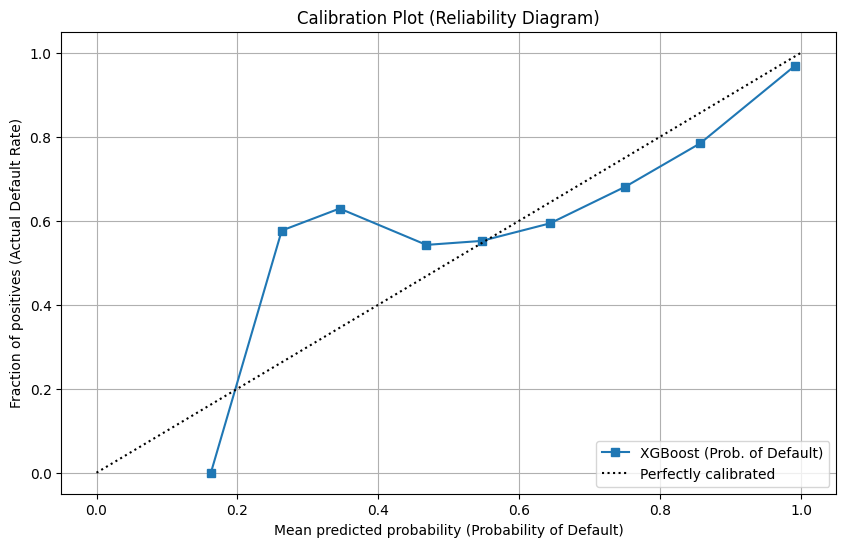

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_pred = df_with_probs['Probability_of_Default']
y_true = 1 - df_with_probs['LoanApproved']
fraction_of_positives, mean_predicted_value = calibration_curve(y_true, prob_pred, n_bins=10)
plt.figure(figsize=(10, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="XGBoost (Prob. of Default)")
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability (Probability of Default)")
plt.ylabel("Fraction of positives (Actual Default Rate)")
plt.title("Calibration Plot (Reliability Diagram)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()